In [4]:
import pandas as pd
df = pd.read_csv('netflix_cleaned.csv')

In [5]:
df.shape

(8790, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
dtypes: int64(1), object(11)
memory usage: 824.2+ KB


Analyze Netflix content growth over time.


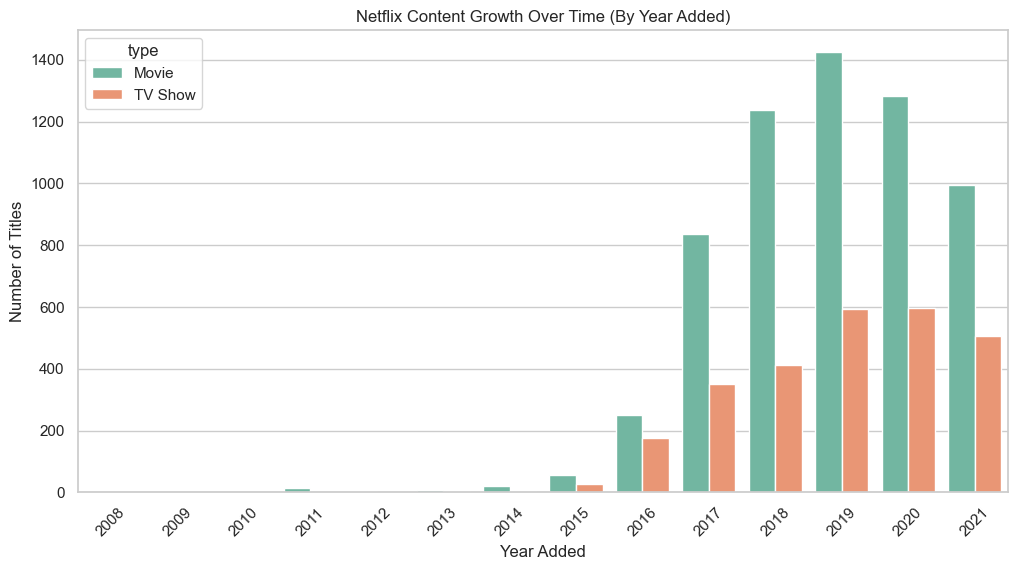

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
df = pd.read_csv('netflix_cleaned.csv')


df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added'] = df['date_added'].dt.year


plt.figure(figsize=(12, 6))
# hue='type' splits the bars into Movies vs TV Shows
sns.countplot(data=df, x='year_added', hue='type', palette='Set2')

plt.title('Netflix Content Growth Over Time (By Year Added)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45) 

plt.show()

 Visualize the distribution of genres, ratings, and content type. 

C:\Users\alinv\AppData\Local\Temp\ipykernel_2404\3302798687.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='pastel', ax=axes[0])
C:\Users\alinv\AppData\Local\Temp\ipykernel_2404\3302798687.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='viridis', ax=axes[1])


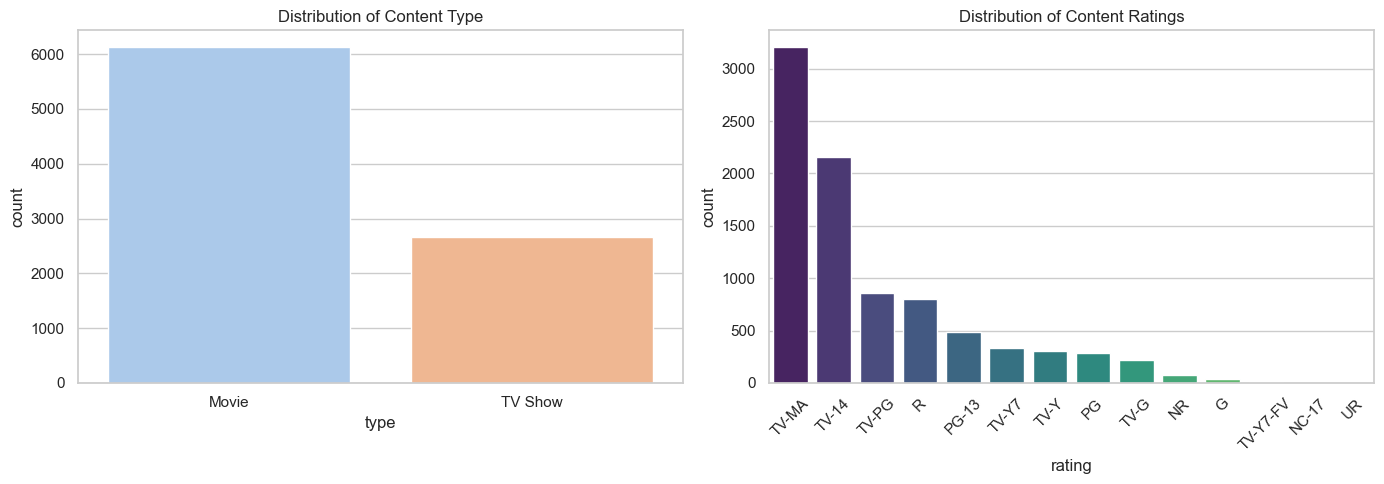

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup and Load Data
sns.set_theme(style="whitegrid")
df = pd.read_csv('netflix_cleaned.csv')

# 2. Setup the Subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. First Chart: Content Type (Movie vs TV Show)
# We tell seaborn to draw this on the first axis: ax=axes[0]
sns.countplot(data=df, x='type', palette='pastel', ax=axes[0])
axes[0].set_title('Distribution of Content Type')

# 4. Second Chart: Ratings Distribution
# We sort the ratings by their count so the biggest bars are on the left
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='viridis', ax=axes[1])
axes[1].set_title('Distribution of Content Ratings')
axes[1].tick_params(axis='x', rotation=45)

# Adjusts spacing so titles don't overlap
plt.tight_layout() 
plt.show()

Identify country-level content contributions. 

In [17]:
import pandas as pd

# 1. Setup and Load Data
df = pd.read_csv('netflix_cleaned.csv')

# 2. Feature Engineering: Content Length Category
def categorize_length(row):
    duration = str(row['duration'])
    type_ = row['type']
    
    if type_ == 'Movie':
        # Extract the number from strings like "90 min"
        mins = int(duration.split(' ')[0])
        if mins < 60: return 'Short Movie'
        elif mins <= 120: return 'Average Movie'
        else: return 'Long Movie'
        
    elif type_ == 'TV Show':
        # Extract the number from strings like "1 Season" or "3 Seasons"
        seasons = int(duration.split(' ')[0])
        if seasons == 1: return 'Single Season'
        else: return 'Multi-Season'

# Apply the function to create the new column
df['Length_Category'] = df.apply(categorize_length, axis=1)

# 3. Feature Engineering: Original vs. Licensed (Proxy)
# We need to recreate the 'year_added' column first since we didn't save it earlier
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year

# Compare release year to the year it was added to Netflix
df['Content_Source'] = df.apply(
    lambda x: 'Likely Original' if x['release_year'] == x['year_added'] else 'Licensed', 
    axis=1
)

# 4. Save the dataset with the new features for Milestone 3!
df.to_csv('netflix_featured.csv', index=False)

print("Feature Engineering Complete!")
print("\n--- Preview of New Features ---")
print(df[['title', 'type', 'Length_Category', 'Content_Source']].head())

Feature Engineering Complete!

--- Preview of New Features ---
                   title     type Length_Category   Content_Source
0   Dick Johnson Is Dead    Movie   Average Movie         Licensed
1          Blood & Water  TV Show    Multi-Season  Likely Original
2              Ganglands  TV Show   Single Season  Likely Original
3  Jailbirds New Orleans  TV Show   Single Season  Likely Original
4           Kota Factory  TV Show    Multi-Season  Likely Original


Create derived features such as “Content Length Category”

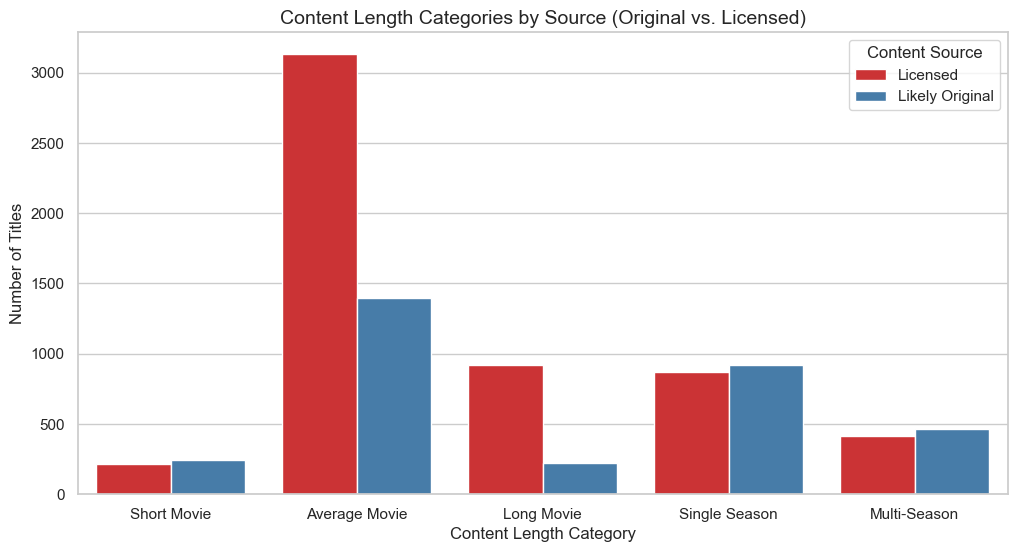

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup and Load Data
sns.set_theme(style="whitegrid")

# Load the dataset we saved at the end of Milestone 2
df = pd.read_csv('netflix_featured.csv')

# 2. Create the Visualization
plt.figure(figsize=(12, 6))

# Define the order so the bars display logically (Movies first, then TV Shows)
category_order = ['Short Movie', 'Average Movie', 'Long Movie', 'Single Season', 'Multi-Season']

# x='Length_Category' creates the main groups
# hue='Content_Source' splits each group by Original vs Licensed
sns.countplot(data=df, x='Length_Category', hue='Content_Source', 
              palette='Set1', order=category_order)

# 3. Formatting
plt.title('Content Length Categories by Source (Original vs. Licensed)', fontsize=14)
plt.xlabel('Content Length Category', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.legend(title='Content Source')

plt.show()

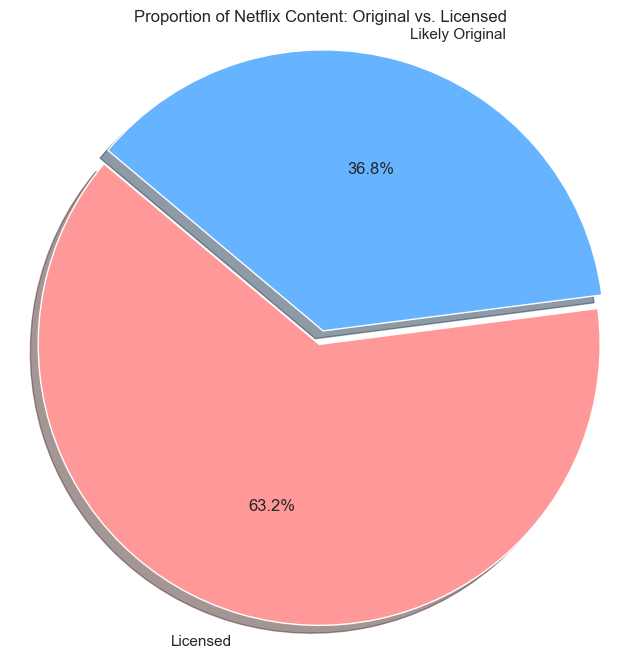

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data with the new features
df = pd.read_csv('netflix_featured.csv')

# 2. Count the occurrences of each source
# This gives us the total number of 'Likely Original' vs 'Licensed'
source_counts = df['Content_Source'].value_counts()

# 3. Create the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(
    source_counts, 
    labels=source_counts.index, 
    autopct='%1.1f%%', # Shows percentages with 1 decimal place
    startangle=140,    # Rotates the chart for a better starting view
    colors=['#ff9999','#66b3ff'], # Soft red and blue colors
    explode=(0.05, 0), # Slightly "explodes" the first slice for emphasis
    shadow=True        # Adds a subtle shadow for a 3D effect
)

plt.title('Proportion of Netflix Content: Original vs. Licensed')
plt.axis('equal') # Ensures the pie is drawn as a circle, not an oval
plt.show()